In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [2]:
full_base_data = pd.read_csv('./data/vattuniemi.csv')
cleaned_base = full_base_data.drop([1, 13])
#display(cleaned_base)

In [3]:
def avg_error(model, x, y):
  preds = model.predict(x)
  residuals = abs(y - preds)
  return np.mean(residuals)


offices = cleaned_base.loc[cleaned_base["Type"] == "office"]

x = offices[["Area"]]
y_con = offices[["Concrete"]]
y_min = offices[["Mineral_wool"]]
y_met = offices[["Metal"]]
y_gla = offices[["Glass"]]

con_model = LinearRegression().fit(x, y_con)
con_coef = con_model.coef_.item()
con_intercept = con_model.intercept_.item()
con_error = avg_error(con_model, x, y_con)

min_model = LinearRegression().fit(x, y_min)
min_coef = min_model.coef_.item()
min_intercept = min_model.intercept_.item()
min_error = avg_error(min_model, x, y_min)

met_model = LinearRegression().fit(x, y_met)
met_coef = met_model.coef_.item()
met_intercept = met_model.intercept_.item()
met_error = avg_error(met_model, x, y_met)

gla_model = LinearRegression().fit(x, y_gla)
gla_coef = gla_model.coef_.item()
gla_intercept = gla_model.intercept_.item()
gla_error = avg_error(gla_model, x, y_gla)

# fig1 = plt.figure(figsize=(12, 6))
# fig2 = plt.figure(figsize=(12, 6))

# ax1 = fig1.add_subplot(121)
# ax2 = fig1.add_subplot(122)
# ax3 = fig2.add_subplot(121)
# ax4 = fig2.add_subplot(122)

# ax1.set_title("Concrete")
# ax1.plot(x, y_con, 'o')
# ax1.plot(x, con_coef*x + con_intercept)

# ax2.set_title("Mineral wool")
# ax2.plot(x, y_min, 'o')
# ax2.plot(x, min_coef*x + min_intercept)

# ax3.set_title("Metal")
# ax3.plot(x, y_met, 'o')
# ax3.plot(x, met_coef*x + met_intercept)

# ax4.set_title("Glass")
# ax4.plot(x, y_gla, 'o')
# ax4.plot(x, gla_coef*x + gla_intercept)

# plt.show()


/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.

In [7]:
generated_data = pd.DataFrame(np.zeros(shape=(100,6)), columns=["Area", "Storeys", "Concrete", "Mineral_wool", "Metal", "Glass"])
storeys = [2, 3, 4, 5, 6]

nr_storeys = np.random.choice(storeys, size=100)
area_mus = nr_storeys * 3000
area_sigmas = np.random.normal(500, 20, 100)
for i in range(100):
  area = np.random.normal(area_mus[i], area_sigmas[i], 1)
  storeys = nr_storeys[i]
  concrete = con_model.predict([area]) + np.random.normal(0, con_error, 1)
  mineral_wool = min_model.predict([area]) + np.random.normal(0, min_error, 1)
  metal = met_model.predict([area]) + np.random.normal(0, met_error, 1)
  glass = gla_model.predict([area]) + np.random.normal(0, gla_error, 1)
  generated_data.loc[i] = area, storeys, concrete, mineral_wool, metal, glass

generated_data.to_csv("./data/generated_data.csv")
areas = generated_data["Area"]


/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/pandas/core/dtypes/cast.py:883: VisibleDeprecationWarning: Creating a

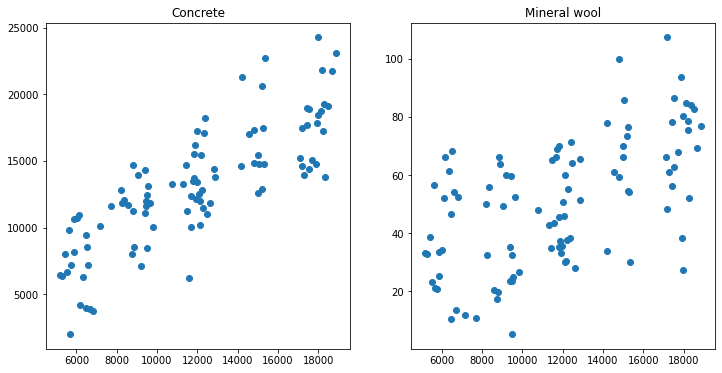

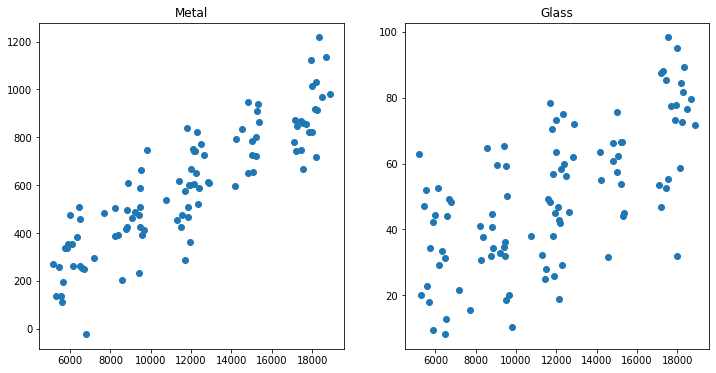

In [6]:
fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))

ax1 = fig1.add_subplot(121)
ax2 = fig1.add_subplot(122)
ax3 = fig2.add_subplot(121)
ax4 = fig2.add_subplot(122)

ax1.set_title("Concrete")
ax1.plot(areas, generated_data["Concrete"], 'o')
#ax1.plot(x, con_coef*x + con_intercept)

ax2.set_title("Mineral wool")
ax2.plot(areas, generated_data["Mineral_wool"], 'o')
#ax2.plot(x, min_coef*x + min_intercept)

ax3.set_title("Metal")
ax3.plot(areas, generated_data["Metal"], 'o')
#ax3.plot(x, met_coef*x + met_intercept)

ax4.set_title("Glass")
ax4.plot(areas, generated_data["Glass"], 'o')
#ax4.plot(x, gla_coef*x + gla_intercept)

plt.show()
